# 04 — 第三代：Hybrid Pipeline + Data Recovery

**方法论定位（第三代，Nemotron-CC 2024）**

三个核心创新：
1. **分类器集成（Classifier Ensembling）**：多个分类器取并集，扩大高质量覆盖面
2. **条件性 Heuristic Bypass**：对高质量文档跳过 heuristic，减少误杀（Nemotron-CC 发现误杀率 18.1%）
3. **合成数据改写（Synthetic Rephrasing）**：低质量数据用 LLM API 改写后回收

### 第三代核心预期指标（论文参考值）

> **口径说明**：保留率 = 分子: 输出文档数 / 分母: 输入文档数。误杀率 = 分子: 被 heuristic 拒绝的高质量(score≥HQ 阈值)文档数 / 分母: 被 heuristic 拒绝的总文档数（Nemotron-CC §4.3）。覆盖增益 = 相对增长率（分子: 集成后 unique token 增量, 分母: 单一分类器 unique token 数）。改写成功率 = 分子: 改写后 score≥0.4 的文档数 / 分母: 送去改写的总文档数。MMLU 口径同 NB00 §1 首表。

| 指标 | 论文参考值 | 论文来源 |
|------|-----------|---------|
| 最终保留率 | ~38% | Nemotron-CC |
| Heuristic 误杀率 | 18.1% | Nemotron-CC §4.3 |
| Ensemble 覆盖增益 | +28% unique token | Nemotron-CC |
| 改写成功率 | ~70-80% | Nemotron-CC §5 |
| 下游效果（8B MMLU） | +5 个百分点 | Nemotron-CC |

> **本 notebook 读取预计算的 pipeline 结果进行可视化分析，不执行 pipeline 本身。** 实际结果与论文预期的对照见下方分析 cells。

## Cell Group A: 分类器集成（Classifier Ensembling）

> **为什么需要集成？单一分类器的盲区问题**
>
> 单一分类器都会有覆盖盲区——某些高质量内容被正样本分布所遗漏。
> 例如：技术博客可能被"百科风格"分类器（Wikipedia 正样本）低估，
> 却被"教育类"分类器（Cosmopedia 正样本）高估。
>
> **本项目的 3 个集成成员**：
> - `fasttext_dclm`：正样本 Wikipedia，偏好百科/学术风格（权重 0.4）
> - `fasttext_edu`：正样本 Cosmopedia 合成教科书，偏好教育/教材风格（权重 0.4）
> - `tfidf_lr`：正样本 Wikipedia，TF-IDF 稀疏特征 + LogisticRegression（权重 0.2）
>
> **Union 策略**：任一分类器认为高质量 → 判为高质量
> - 优点：扩大覆盖面，减少漏网之鱼
> - 缺点：可能引入更多噪声（对比 Intersection 策略）
>
> Nemotron-CC 使用 Union 策略，实现了 +28% unique token 覆盖。

In [1]:
# === 加载配置和预计算结果 ===
# 读取 run_config、gen3 路由汇总、gen3 输出文档、gen1 输出文档。
# 本 notebook 不执行 pipeline，只读取已有结果进行可视化分析。

import sys, json
sys.path.insert(0, '..')
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
from pathlib import Path
from src.utils.config_loader import load_run_config, get_output_path, print_config_summary

run_cfg = load_run_config()
print_config_summary(run_cfg)
mode = run_cfg.get('run_mode', 'smoke_test')

# --- 路径（根据 run_mode 自动定位） ---
gen1_dir = get_output_path(1, run_cfg)
gen3_dir = get_output_path(3, run_cfg)

# --- 加载路由汇总 ---
summary_path = gen3_dir / 'gen3_routing_summary.json'
with open(summary_path) as f:
    summary = json.load(f)
print(f'\n已加载路由汇总 [{mode}]: {summary_path}')

# --- 加载 Gen3 输出文档 ---
gen3_path = gen3_dir / 'gen3_output.jsonl'
gen3_docs = []
with open(gen3_path) as f:
    for line in f:
        gen3_docs.append(json.loads(line))
print(f'已加载 Gen3 输出: {len(gen3_docs):,} 条')

# --- 加载 Gen1 输出文档（Gen3 的输入） ---
gen1_path = gen1_dir / 'gen1_output.jsonl'
gen1_docs = []
with open(gen1_path) as f:
    for line in f:
        gen1_docs.append(json.loads(line))
print(f'已加载 Gen1 输出 (作为 Gen3 输入): {len(gen1_docs):,} 条')

# --- 提取关键数据 ---
routing = summary['routing']
bypass = summary['bypass_analysis']
rephrase = summary['rephrasing']
total_input = routing['total']

ensemble_scores = np.array([d.get('_ensemble_score', 0) for d in gen3_docs])
synthetic_count = sum(1 for d in gen3_docs if d.get('_is_synthetic'))

print(f'\n路由汇总:')
print(f'  输入文档: {total_input:,}')
print(f'  最终保留: {routing["total_kept"]:,}')
print(f'  合成文档: {synthetic_count:,}')

  当前运行模式: FULL_RUN
  2-3小时跑完，产出最终展示级结果
──────────────────────────────────────────────────
  doc_limit       : 100,000
  eval_sample_size: 2,000
  audit_sample_size: 100
  rewrite_count   : 99,999
  random_seed     : 42
  output_subdir   : .../<run_mode>/ = .../full_run/

已加载路由汇总 [full_run]: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/fineweb-pipeline/notebooks/../data/gen3_output/full_run/gen3_routing_summary.json
已加载 Gen3 输出: 750 条
已加载 Gen1 输出 (作为 Gen3 输入): 3,242 条

路由汇总:
  输入文档: 3,242
  最终保留: 695
  合成文档: 55


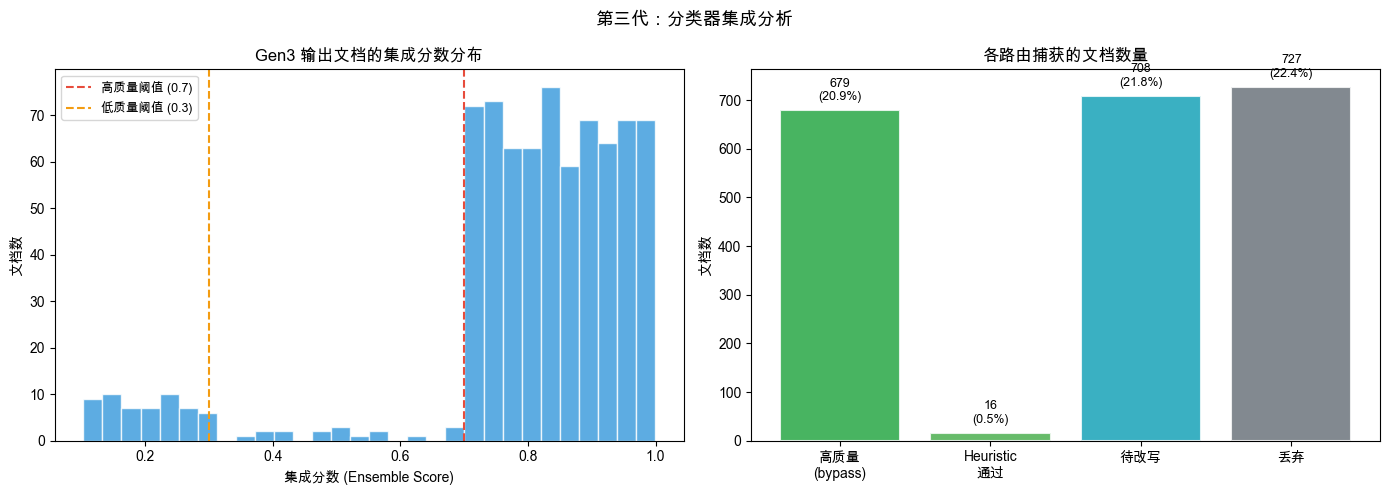

图表已保存: results/figures/04_gen3_ensemble_coverage.png


In [2]:
# === 集成覆盖率可视化 ===
# 左图：Gen3 输出文档的集成分数分布
# 右图：各路由捕获的文档数量对比（柱状图）

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- 左图：集成分数分布 --
axes[0].hist(ensemble_scores, bins=30, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(x=0.7, color='#e74c3c', linestyle='--', linewidth=1.5, label='高质量阈值 (0.7)')
axes[0].axvline(x=0.3, color='#f39c12', linestyle='--', linewidth=1.5, label='低质量阈值 (0.3)')
axes[0].set_xlabel('集成分数 (Ensemble Score)')
axes[0].set_ylabel('文档数')
axes[0].set_title('Gen3 输出文档的集成分数分布')
axes[0].legend(fontsize=9)

# -- 右图：各路由捕获的文档数量 --
route_names = ['高质量\n(bypass)', 'Heuristic\n通过', '待改写', '丢弃']
route_counts = [
    routing['high_quality']['count'],
    routing['heuristic_passed']['count'],
    routing['to_rephrase']['count'],
    routing['discarded']['count'],
]
route_colors = ['#28a745', '#4CAF50', '#17a2b8', '#6c757d']

bars = axes[1].bar(route_names, route_counts, color=route_colors, alpha=0.85,
                    edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, route_counts):
    pct = count / total_input * 100
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(route_counts) * 0.02,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('文档数')
axes[1].set_title('各路由捕获的文档数量')

plt.suptitle('第三代：分类器集成分析', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/04_gen3_ensemble_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存: results/figures/04_gen3_ensemble_coverage.png')

## Cell Group B: 条件性 Heuristic Bypass

> **核心问题：Heuristic 会误杀多少高质量文档？**
>
> Nemotron-CC 的关键发现：对 fastText 判定为高质量的文档，
> 如果再应用 heuristic filter，会误杀 **18.1% 的高质量 token**。
>
> **误杀的原因举例**：
> - 代码文档：含大量特殊字符 → 被 Gopher 的"alpha ratio"规则过滤
> - 技术教程：含代码片段（短行）→ 被 C4 的行规则过滤
> - 问答格式文本：平均句子短 → 被 Gopher 的 avg_sentence_length 过滤
>
> **解决方案（四路路由）**：
> - score ≥ 0.7：直接保留（跳过 heuristic）
> - 0.3 ≤ score < 0.7：应用 heuristic，通过保留，未通过丢弃
> - 0.1 ≤ score < 0.3：送去 LLM 改写
> - score < 0.1：直接丢弃（无改写价值）
>
> 注：MQ 未通过 heuristic 的文档被丢弃（不改写），因为 heuristic 检测的是结构性问题（重复/编码/格式），LLM 改写无法修复这类问题。详见 NB00 §1.3。

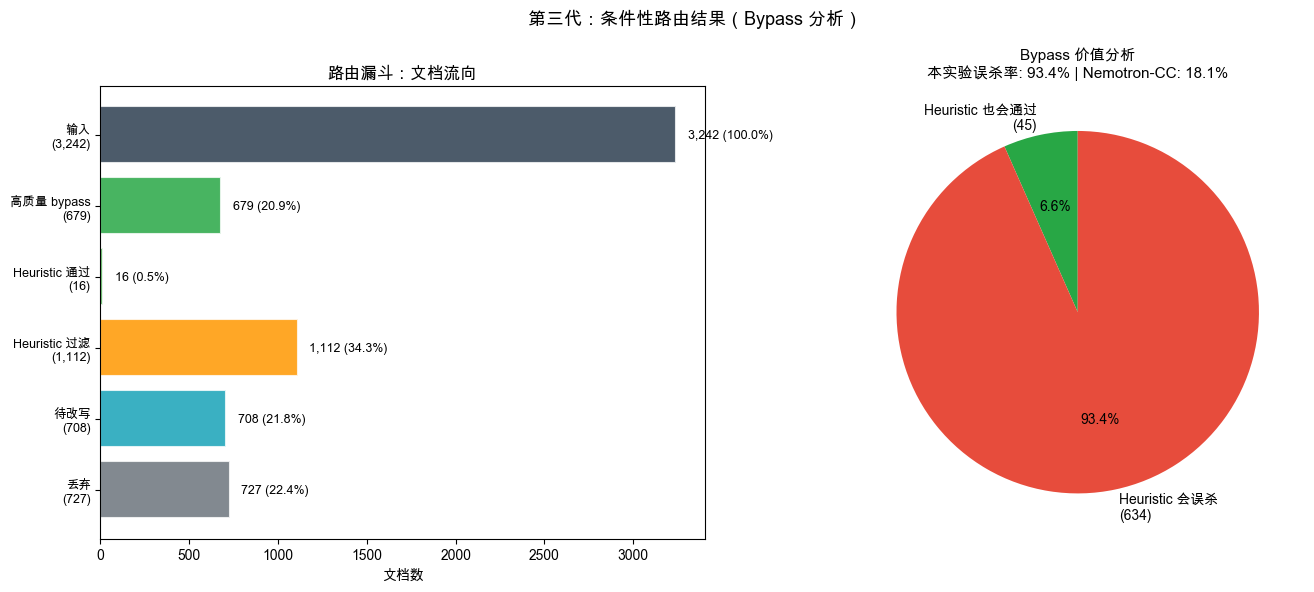

图表已保存: results/figures/04_gen3_routing.png


In [3]:
# === 条件性 Bypass 路由漏斗图 ===
# 可视化路由流程：输入 -> 高质量 bypass -> heuristic -> 改写 -> 丢弃
# 突出 bypass_save_rate（对标 Nemotron-CC 18.1% 发现）

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -- 左图：路由漏斗（横向条形图） --
hq = routing['high_quality']['count']
hp = routing['heuristic_passed']['count']
hf = routing['heuristic_filtered']['count']
tr = routing['to_rephrase']['count']
dc = routing['discarded']['count']

funnel_labels = [
    f'输入\n({total_input:,})',
    f'高质量 bypass\n({hq:,})',
    f'Heuristic 通过\n({hp:,})',
    f'Heuristic 过滤\n({hf:,})',
    f'待改写\n({tr:,})',
    f'丢弃\n({dc:,})',
]
funnel_values = [total_input, hq, hp, hf, tr, dc]
funnel_colors = ['#2c3e50', '#28a745', '#4CAF50', '#FF9800', '#17a2b8', '#6c757d']

y_pos = range(len(funnel_labels))
hbars = axes[0].barh(y_pos, funnel_values, color=funnel_colors, alpha=0.85,
                      edgecolor='white', linewidth=1.5)
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(funnel_labels, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('文档数')
axes[0].set_title('路由漏斗：文档流向', fontweight='bold')
for bar, val in zip(hbars, funnel_values):
    if val > 0:
        axes[0].text(bar.get_width() + max(funnel_values) * 0.02,
                     bar.get_y() + bar.get_height() / 2,
                     f'{val:,} ({val/total_input:.1%})',
                     va='center', fontsize=9)

# -- 右图：Bypass 价值分析 --
hq_count = bypass['high_quality_count']
filtered_count = bypass['would_be_filtered_count']
filtered_rate = bypass['would_be_filtered_rate']
saved_count = hq_count - filtered_count

if hq_count > 0:
    if filtered_count > 0:
        wedge_sizes = [saved_count, filtered_count]
        wedge_labels = [
            f'Heuristic 也会通过\n({saved_count})',
            f'Heuristic 会误杀\n({filtered_count})',
        ]
        wedge_colors = ['#28a745', '#e74c3c']
    else:
        wedge_sizes = [hq_count]
        wedge_labels = [f'Heuristic 也会通过\n({hq_count})']
        wedge_colors = ['#28a745']
    axes[1].pie(wedge_sizes, labels=wedge_labels, colors=wedge_colors,
                autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
else:
    axes[1].text(0.5, 0.5, '无高质量 bypass 文档',
                 ha='center', va='center', fontsize=12, transform=axes[1].transAxes)

title_line2 = f'本实验误杀率: {filtered_rate:.1%} | Nemotron-CC: 18.1%'
axes[1].set_title('Bypass 价值分析\n' + title_line2,
                   fontweight='bold', fontsize=11)

plt.suptitle('第三代：条件性路由结果（Bypass 分析）', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/04_gen3_routing.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存: results/figures/04_gen3_routing.png')

## Cell Group C: 合成数据改写（Synthetic Rephrasing）

> **核心理念：低质量数据不是垃圾，而是待改写的原材料**
>
> Nemotron-CC 的洞见：通过 LLM API 将低质量文本改写为高质量文本，实现数据回收。
>
> **成本效益分析**：
> - Anthropic Opus（`configs/api_config.yaml`）：改写质量最高
> - 改写 300 条文档（full_run 配置）≈ 300 x 500 tokens = 150K tokens
> - 这 300 条变成高质量数据后，价值 >> 成本
>
> **改写后的质量验证**：
> 改写后的文档用**同一套分类器集成**（创新 1 的 3 个分类器组合）重新打分，集成分数 ≥ 0.4 才保留。
> 为什么是 0.4 而非 HQ bypass 阈值 0.7？两者用途不同——0.7 是"已经高质量，跳过 heuristic"的标准；
> 0.4 是"改写后确实有提升"的最低门槛（原始文档分数 0.1-0.3，达到 0.4+ 代表实质性改善）。
> 详见 NB00 §1.3 创新 3 的完整解释。

In [4]:
# === 改写统计 ===
# 显示 LLM 改写的尝试/成功/失败统计

print('=' * 50)
print('  合成数据改写 (Synthetic Rephrasing) 统计')
print('=' * 50)

if rephrase.get('skipped', False):
    print('  状态: 已跳过 (未配置 API Key 或无待改写文档)')
    rephrase_candidates = routing['to_rephrase']['count']
    print(f'  待改写候选: {rephrase_candidates:,} 条')
    print()
    print('  提示: 配置 configs/api_config.yaml 中的 api_key 可启用 LLM 改写')
else:
    attempted = rephrase.get('total_input', 0)
    succeeded = rephrase.get('success', 0)
    failed = rephrase.get('failed', 0)
    print(f'  尝试改写: {attempted:,} 条')
    print(f'  成功: {succeeded:,} 条')
    print(f'  失败: {failed:,} 条')
    if attempted > 0:
        print(f'  成功率: {succeeded/attempted:.1%}')
    print(f'  合成文档占最终输出: {synthetic_count:,} / {len(gen3_docs):,}')

print()
elapsed = summary['elapsed_seconds']
print(f'  Pipeline 执行时间: {elapsed:.2f} 秒')

  合成数据改写 (Synthetic Rephrasing) 统计
  尝试改写: 708 条
  成功: 55 条
  失败: 333 条
  成功率: 7.8%
  合成文档占最终输出: 55 / 750

  Pipeline 执行时间: 520.19 秒


## Cell Group D: 五维数据质量演进（Gen1 输出 vs Gen3 输出）

对 Gen3 过滤前后的数据计算五维质量 profile，量化 Hybrid Pipeline 的综合效果。

| 维度 | 预期变化 |
|------|------|
| 规模 | 保留约 38%（4倍于 Gen2） |
| 质量 | KenLM PPL 降低 |
| 语言 | 英文 ~100% |
| 多样性 | 应保持（Ensemble 扩大覆盖） |
| 毒性 | 应降低或持平 |

In [5]:
# === 五维质量 Profile（Gen1 输出 vs Gen3 输出） ===
from src.evaluation.baseline_profiler import compute_profile, print_profile_summary

sample_size = min(500, len(gen1_docs), len(gen3_docs))

print("正在计算 Gen1 输出的五维 Profile（Gen3 输入）...")
gen1_texts = [d.get('text', '') for d in gen1_docs]
gen1_urls = [d.get('url', '') for d in gen1_docs]
gen1_profile = compute_profile(
    gen1_texts, urls=gen1_urls,
    sample_size=sample_size,
    model_dir='../data/models',
)

print("\n正在计算 Gen3 输出的五维 Profile...")
gen3_texts = [d.get('text', '') for d in gen3_docs]
gen3_urls = [d.get('url', '') for d in gen3_docs]
gen3_profile = compute_profile(
    gen3_texts, urls=gen3_urls,
    sample_size=min(sample_size, len(gen3_docs)),
    model_dir='../data/models',
)

print_profile_summary(gen1_profile, label="Gen1 输出（Gen3 输入）")
print_profile_summary(gen3_profile, label="Gen3 输出（Hybrid Pipeline）")

正在计算 Gen1 输出的五维 Profile（Gen3 输入）...


  加载 KenLM 模型: en.arpa.bin


  加载 SentencePiece: en.sp.model


  KenLM PPL 打分:   0%|          | 0/500 [00:00<?, ?doc/s]

  KenLM PPL 打分:  29%|██▉       | 145/500 [00:00<00:00, 1428.90doc/s]

...

  ☣️  毒性打分:  88%|████████▊ | 14/16 [00:19<00:02,  1.37s/batch]

  ☣️  毒性打分:  94%|█████████▍| 15/16 [00:20<00:01,  1.35s/batch]

  ☣️  毒性打分: 100%|██████████| 16/16 [00:21<00:00,  1.20s/batch]

  ☣️  毒性打分: 100%|██████████| 16/16 [00:21<00:00,  1.32s/batch]


  Gen1 输出（Gen3 输入）

  [规模]
    文档数: 3,242
    总词数: 3,093,686
    平均词数/文档: 954
    中位数词数: 508

  [质量] KenLM Wikipedia Perplexity（采样 500 条）
    中位数: 879  |  均值: 1064
    P10: 425  |  P25: 585  |  P75: 1267  |  P90: 1989
      head:    14 (2.8%) — PPL < 300 (高质量，类 Wikipedia)
    middle:   276 (55.2%) — 300 <= PPL < 1000 (中等质量)
      tail:   210 (42.0%) — PPL >= 1000 (低质量)

  [语言] fastText lid（采样 500 条）
    英文占比: 99.4% (497 / 500)
    检测语言数: 3
    平均置信度: 0.894
    Top 5: en:99.4% | pt:0.4% | fr:0.2%

  [多样性]
    unigram unique ratio: 0.1311
    bigram unique ratio: 0.5982
    trigram unique ratio: 0.8706
    域名 Shannon Entropy: 5.4950 (归一化: 0.9736)

  [毒性] detoxify（采样 500 条）
    toxicity 均值: 0.0251  |  >0.5 占比: 1.80%  |  >0.8 占比: 1.20%
    severe_toxicity: 均值 0.0033, >0.5 = 0.00%
    insult: 均值 0.0116, >0.5 = 0.80%
    identity_attack: 均值 0.0055, >0.5 = 0.40%

  Gen3 输出（Hybrid Pipeline）

  [规模]
    文档数: 750
    总词数: 890,132
    平均词数/文档: 1187
    中位数词数: 593

  [质量] KenLM Wikipedia Perplexi

In [6]:
# === 五维演进对比表 ===
def safe_get(profile, *keys, default='N/A'):
    obj = profile
    for k in keys:
        if isinstance(obj, dict):
            obj = obj.get(k, default)
        else:
            return default
    return obj

print("=" * 80)
print("  五维质量演进对比: Gen1 输出 vs Gen3 输出")
print("=" * 80)
print(f"  {'指标':<35} {'Gen1输出':>18} {'Gen3输出':>18} {'变化':>10}")
print(f"  {'-'*80}")

n_in = safe_get(gen1_profile, 'scale', 'n_docs', default=0)
n_out = safe_get(gen3_profile, 'scale', 'n_docs', default=0)
if n_in:
    print(f"  {'文档数':<35} {n_in:>18,} {n_out:>18,} {n_out/n_in:.1%}")

w_in = safe_get(gen1_profile, 'scale', 'avg_words', default=0)
w_out = safe_get(gen3_profile, 'scale', 'avg_words', default=0)
if isinstance(w_in, (int, float)) and isinstance(w_out, (int, float)):
    print(f"  {'平均词数/文档':<35} {w_in:>18,.0f} {w_out:>18,.0f} {'+' if w_out>w_in else ''}{w_out-w_in:,.0f}")

q_in = safe_get(gen1_profile, 'quality', 'stats', 'median', default=None)
q_out = safe_get(gen3_profile, 'quality', 'stats', 'median', default=None)
if q_in and q_out and isinstance(q_in, (int, float)):
    print(f"  {'KenLM PPL 中位数 (越低越好)':<35} {q_in:>18,.0f} {q_out:>18,.0f} {'better' if q_out<q_in else 'worse'}")
    for bname, label in [('head', 'PPL head(<300)'), ('middle', 'PPL middle'), ('tail', 'PPL tail(>=1000)')]:
        b_in = safe_get(gen1_profile, 'quality', 'buckets', bname, 'ratio', default=0)
        b_out = safe_get(gen3_profile, 'quality', 'buckets', bname, 'ratio', default=0)
        if isinstance(b_in, (int, float)):
            print(f"  {label:<35} {b_in:>18.1%} {b_out:>18.1%}")

en_in = safe_get(gen1_profile, 'language', 'english_ratio', default=0)
en_out = safe_get(gen3_profile, 'language', 'english_ratio', default=0)
if isinstance(en_in, (int, float)):
    print(f"  {'英文占比':<35} {en_in:>18.1%} {en_out:>18.1%}")

for ng, label in [('unigram', 'Unigram unique ratio'), ('bigram', 'Bigram unique ratio')]:
    d_in = safe_get(gen1_profile, 'diversity', 'ngram_diversity', ng, 'unique_ratio', default=None)
    d_out = safe_get(gen3_profile, 'diversity', 'ngram_diversity', ng, 'unique_ratio', default=None)
    if d_in and isinstance(d_in, (int, float)):
        print(f"  {label:<35} {d_in:>18.4f} {d_out:>18.4f}")

de_in = safe_get(gen1_profile, 'diversity', 'domain_entropy', 'normalized_entropy', default=None)
de_out = safe_get(gen3_profile, 'diversity', 'domain_entropy', 'normalized_entropy', default=None)
if de_in and isinstance(de_in, (int, float)):
    print(f"  {'域名 Entropy (归一化)':<35} {de_in:>18.4f} {de_out:>18.4f}")

t_in = safe_get(gen1_profile, 'toxicity', 'toxicity', 'mean', default=None)
t_out = safe_get(gen3_profile, 'toxicity', 'toxicity', 'mean', default=None)
if t_in and isinstance(t_in, (int, float)):
    print(f"  {'毒性均值':<35} {t_in:>18.4f} {t_out:>18.4f}")
    tr_in = safe_get(gen1_profile, 'toxicity', 'toxicity', 'toxic_rate_50', default=0)
    tr_out = safe_get(gen3_profile, 'toxicity', 'toxicity', 'toxic_rate_50', default=0)
    if isinstance(tr_in, (int, float)):
        print(f"  {'毒性>0.5 占比':<35} {tr_in:>18.2%} {tr_out:>18.2%}")

print(f"  {'='*80}")

# 保存
import os
os.makedirs('../results', exist_ok=True)
profiles = {'gen1_output': gen1_profile, 'gen3_output': gen3_profile}
with open('../results/gen3_5dim_profile.json', 'w', encoding='utf-8') as f:
    json.dump(profiles, f, ensure_ascii=False, indent=2, default=str)
print(f"五维 Profile 已保存: results/gen3_5dim_profile.json")

  五维质量演进对比: Gen1 输出 vs Gen3 输出
  指标                                              Gen1输出             Gen3输出         变化
  --------------------------------------------------------------------------------
  文档数                                              3,242                750 23.1%
  平均词数/文档                                            954              1,187 +233
  KenLM PPL 中位数 (越低越好)                               879                606 better
  PPL head(<300)                                    2.8%               8.2%
  PPL middle                                       55.2%              69.2%
  PPL tail(>=1000)                                 42.0%              22.6%
  英文占比                                             99.4%              92.0%
  Unigram unique ratio                            0.1311             0.1163
  Bigram unique ratio                             0.5982             0.5731
  域名 Entropy (归一化)                                0.9736             0.9754
  毒性均值               

## Cell Group E: 分类器集成健康度 + Error Analysis + Distribution Shift

> **三合一检查**：对 Gen3 的分类器集成进行全面诊断。
>
> **1. 分类器健康度**：各集成成员的分离度和分数展开度
> **2. Error Analysis**：被丢弃的高分文档（潜在冤杀）和被保留的低分文档（潜在错放）
> **3. Distribution Shift Detection**：训练数据（Wikipedia/Cosmopedia + CC WET）vs 推理数据（Gen1 输出）的分布偏移

In [7]:
# === Cell E: Gen3 分类器集成 — 健康度 + Error Analysis + Distribution Shift ===
import re
from src.evaluation.quality_classifier import EvalQualityClassifier

# --- 1. 分类器健康度 ---
print("=" * 70)
print("  Gen3 分类器集成健康度检查")
print("=" * 70)

# 集成分数分布
all_ensemble = np.array([d.get('_ensemble_score', 0) for d in gen1_docs[:len(gen1_docs)]])
# 从路由汇总获取阈值
hq_threshold = routing.get('high_quality_threshold', 0.7)
med_threshold = routing.get('medium_threshold', 0.3)

# 尝试从 gen3_docs 获取集成分数
if len(all_ensemble) == 0 or all_ensemble.max() == 0:
    # 从 stage_metrics 获取
    stage_path = gen3_dir / 'gen3_stage_metrics.json'
    if stage_path.exists():
        with open(stage_path) as f:
            stage_metrics = json.load(f)
        print("  (从 stage_metrics 加载指标)")

# Gen3 输出文档的集成分数
gen3_ensemble = np.array([d.get('_ensemble_score', 0) for d in gen3_docs])
print(f"\n  Gen3 输出文档集成分数: mean={gen3_ensemble.mean():.4f}, P50={np.median(gen3_ensemble):.4f}, P90={np.percentile(gen3_ensemble, 90):.4f}")
print(f"  高质量阈值: {hq_threshold} | 中等阈值: {med_threshold}")

# 加载 eval classifier 检查独立质量评估
eval_clf = EvalQualityClassifier()
eval_clf_path = Path('../results/quality_scores/eval_classifier.bin')
if eval_clf_path.exists():
    eval_clf._load(str(eval_clf_path))
    gen3_eval = eval_clf.score_batch([d['text'] for d in gen3_docs])
    gen1_eval = eval_clf.score_batch([d['text'] for d in gen1_docs[:500]])
    separation = gen3_eval.mean() - gen1_eval.mean()
    print(f"\n  独立 Eval 分类器分离度（Gen3 输出 vs Gen1 全量）:")
    print(f"    Gen3 eval 均分: {gen3_eval.mean():.4f} | Gen1 eval 均分: {gen1_eval.mean():.4f}")
    print(f"    分离度: {separation:.4f} {'✅' if separation > 0.1 else '⚠️'}")

# --- 2. Error Analysis ---
print(f"\n{'=' * 70}")
print("  Error Analysis: 路由决策边界审查")
print("=" * 70)

def safe_text(text, max_len=250):
    clean = re.sub(r'[\ud800-\udfff]', '', text)
    return clean[:max_len] + '...' if len(clean) > max_len else clean

# 被丢弃的文档中分数最高的（potentialed false negative）
discarded = [d for d in gen1_docs if d.get('_ensemble_score', 0) > 0]
# 找不在 gen3_docs 中的 gen1 文档（通过 text 前 100 字符匹配）
gen3_keys = set(d['text'][:100] for d in gen3_docs)
not_kept = [(d, d.get('_ensemble_score', 0)) for d in gen1_docs
            if d['text'][:100] not in gen3_keys and d.get('_ensemble_score', 0) > 0]
not_kept_sorted = sorted(not_kept, key=lambda x: x[1], reverse=True)

if not_kept_sorted:
    print(f"\n  📋 被丢弃但集成分数最高的 5 条（潜在 false negative）:")
    print("-" * 70)
    for i, (doc, score) in enumerate(not_kept_sorted[:5]):
        text_preview = safe_text(doc['text'])
        print(f"\n  [{i+1}] ensemble={score:.4f} | {len(doc['text'].split())} 词")
        print(f"      {text_preview}")

# 被保留的文档中分数最低的（potential false positive）
kept_sorted = sorted([(d, d.get('_ensemble_score', 0)) for d in gen3_docs],
                     key=lambda x: x[1])
print(f"\n\n  📋 被保留但集成分数最低的 5 条（潜在 false positive）:")
print("-" * 70)
for i, (doc, score) in enumerate(kept_sorted[:5]):
    text_preview = safe_text(doc['text'])
    route = doc.get('_route', 'unknown')
    print(f"\n  [{i+1}] ensemble={score:.4f} | route={route} | {len(doc['text'].split())} 词")
    print(f"      {text_preview}")

# --- 3. Distribution Shift ---
print(f"\n{'=' * 70}")
print("  Distribution Shift Detection")
print("=" * 70)

# 训练数据 vs 推理数据长度对比
wiki_path = Path('../data/reference/wikipedia_abstracts.jsonl')
cosmo_path = Path('../data/reference/cosmopedia_edu.jsonl')
raw_path = Path('../data/raw/cc_wet_sample.jsonl')

sources = {}
for name, path, field in [('Wikipedia', wiki_path, 'text'), ('Cosmopedia', cosmo_path, 'text'), ('CC WET', raw_path, 'text')]:
    if path.exists():
        lens = []
        with open(path) as f:
            for i, line in enumerate(f):
                if i >= 500: break
                try: lens.append(len(json.loads(line).get(field, '').split()))
                except: pass
        sources[name] = lens

gen1_lens = [len(d['text'].split()) for d in gen1_docs]

print(f"\n  文本长度对比:")
print(f"  {'数据集':<25} {'均长':<10} {'P50':<10} {'P90':<10} {'角色'}")
print("  " + "-" * 70)
for name, lens in sources.items():
    role = '训练正样本' if name in ('Wikipedia', 'Cosmopedia') else '训练负样本'
    print(f"  {name:<25} {np.mean(lens):<10.0f} {np.median(lens):<10.0f} {np.percentile(lens,90):<10.0f} {role}")
print(f"  {'Gen1 输出(推理数据)':<25} {np.mean(gen1_lens):<10.0f} {np.median(gen1_lens):<10.0f} {np.percentile(gen1_lens,90):<10.0f} 推理目标")

# 关键发现
print(f"\n  关键发现:")
if 'CC WET' in sources:
    shift = np.mean(gen1_lens) / np.mean(sources['CC WET'])
    print(f"    Gen1 输出 vs CC WET 长度比: {shift:.2f}x → 推理数据与训练负样本长度{'接近' if abs(shift - 1) < 0.3 else '有偏移'}")
if 'Wikipedia' in sources:
    shift = np.mean(gen1_lens) / np.mean(sources['Wikipedia'])
    print(f"    Gen1 输出 vs Wikipedia 长度比: {shift:.1f}x → 需要自适应截断（只截断负样本到 Wikipedia p90）")
print(f"\n{'=' * 70}")

  Gen3 分类器集成健康度检查
  (从 stage_metrics 加载指标)

  Gen3 输出文档集成分数: mean=0.7933, P50=0.8333, P90=0.9669
  高质量阈值: 0.7 | 中等阈值: 0.3
  ✅ 评估分类器已加载: ../results/quality_scores/eval_classifier.bin



  独立 Eval 分类器分离度（Gen3 输出 vs Gen1 全量）:


    Gen3 eval 均分: 0.7699 | Gen1 eval 均分: 0.6949
    分离度: 0.0750 ⚠️

  Error Analysis: 路由决策边界审查


  📋 被保留但集成分数最低的 5 条（潜在 false positive）:
----------------------------------------------------------------------

  [1] ensemble=0.1034 | route=unknown | 57 词
      # 商业分析师认证入门指南

商业分析是一个不断发展的专业领域，对于初入行业的从业者而言，了解主要的认证体系及其适用范围至关重要。本文将介绍几种面向不同经验层级的商业分析师认证，帮助初学者规划职业发展路径。

## 什么是商业分析师认证？

商业分析师认证是由专业机构颁发的资质证书，用以证明持证者在商业分析领域具备相应的知识和能力。选择合适的认证不仅能提升专业竞争力，还能增加收入潜力，并为未来的职业晋升奠定基础。

## 主要认证类型

### ECBA（商业分析入门认证）

ECBA 是国际商...

  [2] ensemble=0.1093 | route=unknown | 98 词
      Howarth, Sue; Scott, Linda; Collins, Philip and Blackmore, Karen (2010) "Wow Factors!" Paper presented at the Association for Science Education Annual Conference, 6–9 January 2010, University of Nottingham.

This conference paper is catalogued in the...

  [3] ensemble=0.1096 | route=unknown | 50 词
      Randy Lowens是一位居住在肯塔基州罗克卡斯尔县的作家，同时也是一位在家教育女儿的父亲。他成长于佐治亚州北部的丘陵地带，早年从事焊接、机械加工和空调维修等蓝领工作。出于对雇主种种不公的愤怒，他开始为左翼刊物撰稿，由此走上写作道路。

Lowens


  文本长度对比:
  数据集                       均长         P50        P90        角色
  ----------------------------------------------------------------------
  Wikipedia                 74         69         121        训练正样本
  Cosmopedia                536        495        791        训练正样本
  CC WET                    864        345        1546       训练负样本
  Gen1 输出(推理数据)             954        508        1969       推理目标

  关键发现:
    Gen1 输出 vs CC WET 长度比: 1.10x → 推理数据与训练负样本长度接近
    Gen1 输出 vs Wikipedia 长度比: 12.9x → 需要自适应截断（只截断负样本到 Wikipedia p90）



In [8]:
# === 第三代最终汇总 + 与第二代对比 ===

total_kept = len(gen3_docs)  # 包含合成文档
retention_rate = total_kept / total_input
gen2_approx = int(total_input * 0.10)  # 第二代约保留 top-10%

print('=' * 60)
print('  第三代 Hybrid Pipeline -- 最终结论')
print('=' * 60)
print(f'  输入文档数: {total_input:,}')
print(f'  最终输出: {total_kept:,} 条')
hq_c = routing['high_quality']['count']
hp_c = routing['heuristic_passed']['count']
print(f'  |-- 高质量(bypass): {hq_c:,} 条')
print(f'  |-- 中等(heuristic通过): {hp_c:,} 条')
print(f'  +-- 合成数据(改写): {synthetic_count:,} 条')
print(f'  总保留率: {retention_rate:.1%}')
print()
print('  对比第二代（top-10%）:')
print(f'  第二代输出约: {gen2_approx:,} 条')
print(f'  第三代输出约: {total_kept:,} 条')
if gen2_approx > 0:
    print(f'  数据量倍数: {total_kept/gen2_approx:.1f}x')
print()

# 汇总表格
header_route = '路由'
header_count = '文档数'
header_pct = '占比'
print('路由明细表：')
print(f'{header_route:<20} {header_count:>8} {header_pct:>8}')
print('-' * 38)
for name, key in [('高质量 bypass', 'high_quality'),
                   ('Heuristic 通过', 'heuristic_passed'),
                   ('Heuristic 过滤', 'heuristic_filtered'),
                   ('待改写', 'to_rephrase'),
                   ('丢弃', 'discarded')]:
    c = routing[key]['count']
    r = routing[key]['rate']
    print(f'{name:<20} {c:>8,} {r:>8.1%}')
print('-' * 38)
footer_label = '最终保留'
print(f'{footer_label:<20} {total_kept:>8,} {retention_rate:>8.1%}')
print()
print('  ML 检视指标（健康度参考）：')
print(f'    Bypass 误杀率: {bypass["would_be_filtered_rate"]:.1%}  (Nemotron-CC 参考: 18.1%)')
print(f'      口径: 被 heuristic 拒绝但分类器判为高质量的文档数 / 被 heuristic 拒绝的总文档数')
if rephrase and not rephrase.get("skipped", False):
    rephrase_total = rephrase.get('total_input', 0)
    rephrase_ok = rephrase.get('success', 0)
    rephrase_rate = rephrase_ok / rephrase_total if rephrase_total > 0 else 0
    print(f'    改写成功率: {rephrase_rate:.1%}  (Nemotron-CC 参考: 70-80%)')
    print(f'      口径: 改写后集成分数 >= 门禁阈值的文档数 / 送去改写的文档总数')
print()
print('  下一步 -> Notebook 05：去重分析')

  第三代 Hybrid Pipeline -- 最终结论
  输入文档数: 3,242
  最终输出: 750 条
  |-- 高质量(bypass): 679 条
  |-- 中等(heuristic通过): 16 条
  +-- 合成数据(改写): 55 条
  总保留率: 23.1%

  对比第二代（top-10%）:
  第二代输出约: 324 条
  第三代输出约: 750 条
  数据量倍数: 2.3x

路由明细表：
路由                        文档数       占比
--------------------------------------
高质量 bypass                679    20.9%
Heuristic 通过               16     0.5%
Heuristic 过滤            1,112    34.3%
待改写                       708    21.8%
丢弃                        727    22.4%
--------------------------------------
最终保留                      750    23.1%

  ML 检视指标（健康度参考）：
    Bypass 误杀率: 93.4%  (Nemotron-CC 参考: 18.1%)
      口径: 被 heuristic 拒绝但分类器判为高质量的文档数 / 被 heuristic 拒绝的总文档数
    改写成功率: 7.8%  (Nemotron-CC 参考: 70-80%)
      口径: 改写后集成分数 >= 门禁阈值的文档数 / 送去改写的文档总数

  下一步 -> Notebook 05：去重分析
